# Pipeline Augmentasi Merapi (SMOTE-Style Regresi, Split 60/20/20)
Notebook ini khusus untuk 1 gunung (Merapi) dengan tujuan menyiapkan data train/val/test yang siap untuk modeling multi-output (jarak_km, luas_km2, sudut_deg, radius_km).

Alur utama:
1. Load dan validasi data
2. Feature engineering berbasis domain abu vulkanik
3. Split train/val/test = 60/20/20
4. Seleksi fitur terbaik (mutual information, hanya dari train)
5. Scaling (standard/minmax)
6. Augmentasi train dengan SMOTE-style untuk regresi multi-output
7. Simpan output preprocessing + scaler + metadata

In [1]:
from pathlib import Path
from time import perf_counter
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
# Konfigurasi path dan parameter utama
step_start = perf_counter()

DATA_PATH = Path('merapi-ash-hysplit.csv')
OUTPUT_DIR = Path('preprocessing_outputs_merapi_smote_v2')
SCALER_DIR = OUTPUT_DIR / 'scalers'
REPORT_DIR = OUTPUT_DIR / 'reports'

for d in [OUTPUT_DIR, SCALER_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
OPTIONAL_DROP_COLS = ['id', 'timestamp', 'volcano_filter']

RANDOM_STATE = 42
TOP_K_FEATURES = 14
SCALER_TYPE = 'standard'  # opsi: 'standard' atau 'minmax'

# Kontrol augmentasi yang lebih aman untuk data kecil
TARGET_TRAIN_SIZE = 150
MAX_AUG_RATIO = 6.0      # batasi agar jumlah sintetis tidak terlalu ekstrem
N_NEIGHBORS = 5
FOCUS_QUANTILE = 0.80

process_times = {}
process_times['setup'] = perf_counter() - step_start
print(f'Waktu setup: {process_times["setup"]:.6f} detik')
print('DATA_PATH:', DATA_PATH.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())

Waktu setup: 0.001593 detik
DATA_PATH: D:\Projects\volcanic_ash\merapi\merapi-ash-hysplit.csv
OUTPUT_DIR: D:\Projects\volcanic_ash\merapi\preprocessing_outputs_merapi_smote_v2


In [3]:
# Load data dan validasi awal
step_start = perf_counter()

if not DATA_PATH.exists():
    raise FileNotFoundError(f'File tidak ditemukan: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

missing_targets = [c for c in TARGET_COLS if c not in df.columns]
if missing_targets:
    raise ValueError(f'Target tidak ditemukan di dataset: {missing_targets}')

process_times['load_data'] = perf_counter() - step_start
print(f'Waktu load_data: {process_times["load_data"]:.6f} detik')
print('Shape awal:', df.shape)
display(df.head(3))

Waktu load_data: 0.006750 detik
Shape awal: (42, 16)


,id,timestamp,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km
0,1,2024-06-11 07:34:00 UTC,Merapi,Yellow,-7.54194,110.44194,2968,1000,4.7,270,50,30,32.511505,614.390650,303.257335,18.304149
1,2,2024-01-24 08:56:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1000,8.0,135,51,168,27.761756,460.792988,37.901873,15.892819
2,3,2023-03-15 03:36:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1200,7.1,90,65,133,44.625714,614.214150,265.635506,23.934437


In [4]:
# Feature engineering berbasis domain
step_start = perf_counter()

def add_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    dfx = dataframe.copy()

    # Timestamp -> fitur siklik waktu
    dfx['timestamp_parsed'] = pd.to_datetime(dfx['timestamp'], utc=True, errors='coerce')
    dfx['hour_utc'] = dfx['timestamp_parsed'].dt.hour.fillna(0).astype(int)
    dfx['month'] = dfx['timestamp_parsed'].dt.month.fillna(1).astype(int)

    dfx['hour_sin'] = np.sin(2 * np.pi * dfx['hour_utc'] / 24.0)
    dfx['hour_cos'] = np.cos(2 * np.pi * dfx['hour_utc'] / 24.0)
    dfx['month_sin'] = np.sin(2 * np.pi * dfx['month'] / 12.0)
    dfx['month_cos'] = np.cos(2 * np.pi * dfx['month'] / 12.0)

    # Alert level ordinal
    alert_map = {'Green': 1, 'Yellow': 2, 'Orange': 3, 'Red': 4}
    dfx['alert_level_num'] = dfx['alert_level'].map(alert_map).fillna(0)

    # Sudut angin -> komponen vektor
    wind_rad = np.deg2rad(dfx['arah_angin_deg'].astype(float))
    wind_speed = dfx['kec_angin_km_jam'].astype(float)
    dfx['wind_u'] = wind_speed * np.cos(wind_rad)
    dfx['wind_v'] = wind_speed * np.sin(wind_rad)

    # Interaksi fisik sederhana
    dfx['plume_to_elevation_ratio'] = dfx['tinggi_letusan_m'].astype(float) / (dfx['elevation'].astype(float) + 1.0)
    dfx['eruption_energy_proxy'] = dfx['tinggi_letusan_m'].astype(float) * dfx['amplitudo'].astype(float)
    dfx['wind_plume_interaction'] = wind_speed * dfx['tinggi_letusan_m'].astype(float)
    dfx['duration_amplitude_interaction'] = dfx['duration'].astype(float) * dfx['amplitudo'].astype(float)

    # Tangani missing numerik
    numeric_cols = dfx.select_dtypes(include=[np.number]).columns
    dfx[numeric_cols] = dfx[numeric_cols].replace([np.inf, -np.inf], np.nan)
    dfx[numeric_cols] = dfx[numeric_cols].fillna(dfx[numeric_cols].median())

    return dfx

df_feat = add_engineered_features(df)

process_times['feature_engineering'] = perf_counter() - step_start
print(f'Waktu feature_engineering: {process_times["feature_engineering"]:.6f} detik')
print('Shape setelah feature engineering:', df_feat.shape)

Waktu feature_engineering: 0.162068 detik
Shape setelah feature engineering: (42, 30)


In [5]:
# Split train/val/test = 60/20/20 (dengan stratifikasi target proxy bila memungkinkan)
step_start = perf_counter()

if len(df_feat) < 15:
    raise ValueError('Data terlalu sedikit untuk split stabil. Minimal 15 baris disarankan.')

stratify_col = None
try:
    # Gunakan bin quantile dari luas_km2 agar distribusi area lebih seimbang per split
    proxy_bins = pd.qcut(df_feat['luas_km2'], q=4, labels=False, duplicates='drop')
    if proxy_bins.nunique() >= 2:
        stratify_col = proxy_bins
except Exception:
    stratify_col = None

train_df, temp_df = train_test_split(
    df_feat,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=stratify_col
 )

temp_stratify = None
if stratify_col is not None:
    temp_stratify = stratify_col.loc[temp_df.index]

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=temp_stratify
 )

process_times['split_data'] = perf_counter() - step_start
print(f'Waktu split_data: {process_times["split_data"]:.6f} detik')
print('Train:', train_df.shape)
print('Val  :', val_df.shape)
print('Test :', test_df.shape)

Waktu split_data: 0.029871 detik
Train: (25, 30)
Val  : (8, 30)
Test : (9, 30)


In [6]:
# Menyusun kandidat fitur dan seleksi fitur terbaik dari train
step_start = perf_counter()

drop_cols = TARGET_COLS + [c for c in OPTIONAL_DROP_COLS if c in train_df.columns] + ['timestamp_parsed']
candidate_feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train_raw = train_df[candidate_feature_cols].copy()
X_val_raw = val_df[candidate_feature_cols].copy()
X_test_raw = test_df[candidate_feature_cols].copy()

y_train_raw = train_df[TARGET_COLS].copy()
y_val_raw = val_df[TARGET_COLS].copy()
y_test_raw = test_df[TARGET_COLS].copy()

# Encoding kategorikal konsisten: fit kategori di train, lalu terapkan ke val/test
categorical_cols = [c for c in X_train_raw.columns if X_train_raw[c].dtype == 'object']
category_maps = {}
for col in categorical_cols:
    train_cat = pd.Categorical(X_train_raw[col])
    categories = list(train_cat.categories)
    category_maps[col] = categories

    X_train_raw[col] = pd.Categorical(X_train_raw[col], categories=categories).codes
    X_val_raw[col] = pd.Categorical(X_val_raw[col], categories=categories).codes
    X_test_raw[col] = pd.Categorical(X_test_raw[col], categories=categories).codes

    # Unknown category di val/test menjadi -1
    X_val_raw[col] = X_val_raw[col].replace(-1, np.nan).fillna(-1)
    X_test_raw[col] = X_test_raw[col].replace(-1, np.nan).fillna(-1)

mi_rows = []
for tgt in TARGET_COLS:
    scores = mutual_info_regression(X_train_raw, y_train_raw[tgt], random_state=RANDOM_STATE)
    for feat, s in zip(X_train_raw.columns, scores):
        mi_rows.append({'target': tgt, 'feature': feat, 'mi_score': float(s)})

mi_df = pd.DataFrame(mi_rows)
mi_rank = (
    mi_df.groupby('feature', as_index=False)['mi_score']
    .mean()
    .sort_values('mi_score', ascending=False)
    .reset_index(drop=True)
)

selected_feature_cols = mi_rank.head(min(TOP_K_FEATURES, len(mi_rank)))['feature'].tolist()

X_train_raw = X_train_raw[selected_feature_cols].copy()
X_val_raw = X_val_raw[selected_feature_cols].copy()
X_test_raw = X_test_raw[selected_feature_cols].copy()

mi_rank.to_csv(REPORT_DIR / 'feature_importance_mutual_info.csv', index=False)

process_times['feature_selection'] = perf_counter() - step_start
print(f'Waktu feature_selection: {process_times["feature_selection"]:.6f} detik')
print('Jumlah kandidat fitur:', len(candidate_feature_cols))
print('Jumlah fitur terpilih:', len(selected_feature_cols))
print('Fitur terpilih:', selected_feature_cols)
display(mi_rank.head(20))

Waktu feature_selection: 0.100170 detik
Jumlah kandidat fitur: 22
Jumlah fitur terpilih: 14
Fitur terpilih: ['eruption_energy_proxy', 'tinggi_letusan_m', 'plume_to_elevation_ratio', 'amplitudo', 'wind_plume_interaction', 'month_cos', 'wind_v', 'month', 'month_sin', 'arah_angin_deg', 'duration_amplitude_interaction', 'hour_sin', 'wind_u', 'kec_angin_km_jam']


,feature,mi_score
0,eruption_energy_proxy,0.384362
1,tinggi_letusan_m,0.273644
2,plume_to_elevation_ratio,0.267275
3,amplitudo,0.172051
4,wind_plume_interaction,0.138095
5,month_cos,0.107558
6,wind_v,0.095926
7,month,0.093604
8,month_sin,0.092827
9,arah_angin_deg,0.052088


In [7]:
# Scaling fitur dan target
step_start = perf_counter()

if SCALER_TYPE == 'standard':
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
elif SCALER_TYPE == 'minmax':
    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()
else:
    raise ValueError("SCALER_TYPE harus 'standard' atau 'minmax'")

X_train_scaled = x_scaler.fit_transform(X_train_raw)
X_val_scaled = x_scaler.transform(X_val_raw)
X_test_scaled = x_scaler.transform(X_test_raw)

y_train_scaled = y_scaler.fit_transform(y_train_raw)
y_val_scaled = y_scaler.transform(y_val_raw)
y_test_scaled = y_scaler.transform(y_test_raw)

process_times['scaling'] = perf_counter() - step_start
print(f'Waktu scaling: {process_times["scaling"]:.6f} detik')
print('Scaler yang digunakan:', SCALER_TYPE)

Waktu scaling: 0.013381 detik
Scaler yang digunakan: standard


In [8]:
# SMOTE-style untuk regresi multi-output (interpolasi antartetangga terdekat)
step_start = perf_counter()

def smote_regression_multioutput(
    X_scaled: np.ndarray,
    y_scaled: np.ndarray,
    n_new_samples: int,
    n_neighbors: int = 5,
    focus_quantile: float = 0.80,
    random_state: int = 42
):
    rng = np.random.default_rng(random_state)

    if len(X_scaled) < 2 or n_new_samples <= 0:
        return X_scaled.copy(), y_scaled.copy()

    target_center = y_scaled.mean(axis=0)
    rarity_score = np.linalg.norm(y_scaled - target_center, axis=1)
    threshold = np.quantile(rarity_score, focus_quantile)
    focus_idx = np.where(rarity_score >= threshold)[0]

    if len(focus_idx) < 2:
        focus_idx = np.arange(len(X_scaled))

    k = min(max(2, n_neighbors), len(X_scaled))
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_scaled)

    x_new_list = []
    y_new_list = []

    for _ in range(n_new_samples):
        i = int(rng.choice(focus_idx))
        neighbors = nn.kneighbors(X_scaled[i].reshape(1, -1), return_distance=False)[0]
        neighbors = neighbors[neighbors != i]

        if len(neighbors) == 0:
            j = i
        else:
            j = int(rng.choice(neighbors))

        lam = float(rng.uniform(0.1, 0.9))

        x_new = X_scaled[i] + lam * (X_scaled[j] - X_scaled[i])
        y_new = y_scaled[i] + lam * (y_scaled[j] - y_scaled[i])

        x_new_list.append(x_new)
        y_new_list.append(y_new)

    X_aug = np.vstack([X_scaled, np.asarray(x_new_list)])
    y_aug = np.vstack([y_scaled, np.asarray(y_new_list)])

    return X_aug, y_aug

# Target jumlah train yang realistis untuk data kecil
n_train_original = len(X_train_scaled)
n_target_from_size = max(0, TARGET_TRAIN_SIZE - n_train_original)
n_target_from_ratio = int(n_train_original * MAX_AUG_RATIO)
n_new = int(min(n_target_from_size, n_target_from_ratio))

X_train_aug_scaled, y_train_aug_scaled = smote_regression_multioutput(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled,
    n_new_samples=n_new,
    n_neighbors=N_NEIGHBORS,
    focus_quantile=FOCUS_QUANTILE,
    random_state=RANDOM_STATE
)

process_times['smote_augmentation'] = perf_counter() - step_start
print(f'Waktu smote_augmentation: {process_times["smote_augmentation"]:.6f} detik')
print('Train asli:', X_train_scaled.shape, y_train_scaled.shape)
print('Target train size:', TARGET_TRAIN_SIZE)
print('Batas max ratio:', MAX_AUG_RATIO)
print('Jumlah sintetis dipakai:', n_new)
print('Train setelah augmentasi:', X_train_aug_scaled.shape, y_train_aug_scaled.shape)

Waktu smote_augmentation: 0.043860 detik
Train asli: (25, 14) (25, 4)
Target train size: 150
Batas max ratio: 6.0
Jumlah sintetis dipakai: 125
Train setelah augmentasi: (150, 14) (150, 4)


In [9]:
# Konversi balik ke skala raw dan simpan output preprocessing
step_start = perf_counter()

X_train_aug_raw = pd.DataFrame(
    x_scaler.inverse_transform(X_train_aug_scaled),
    columns=selected_feature_cols
)
y_train_aug_raw = pd.DataFrame(
    y_scaler.inverse_transform(y_train_aug_scaled),
    columns=TARGET_COLS
)

train_aug_df = pd.concat([X_train_aug_raw, y_train_aug_raw], axis=1)
val_out_df = pd.concat([X_val_raw.reset_index(drop=True), y_val_raw.reset_index(drop=True)], axis=1)
test_out_df = pd.concat([X_test_raw.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)

train_aug_df.to_csv(OUTPUT_DIR / 'merapi_train_augmented_smote.csv', index=False)
val_out_df.to_csv(OUTPUT_DIR / 'merapi_val_smote.csv', index=False)
test_out_df.to_csv(OUTPUT_DIR / 'merapi_test_smote.csv', index=False)

with open(SCALER_DIR / 'x_scaler.pkl', 'wb') as f:
    pickle.dump(x_scaler, f)
with open(SCALER_DIR / 'y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)

metadata = {
    'data_path': str(DATA_PATH),
    'target_cols': TARGET_COLS,
    'selected_feature_cols': selected_feature_cols,
    'split_ratio': {'train': 0.6, 'val': 0.2, 'test': 0.2},
    'scaler_type': SCALER_TYPE,
    'categorical_maps': category_maps,
    'augmentation': {
        'method': 'smote_style_regression_knn_interpolation',
        'target_train_size': TARGET_TRAIN_SIZE,
        'max_aug_ratio': MAX_AUG_RATIO,
        'n_neighbors': N_NEIGHBORS,
        'focus_quantile': FOCUS_QUANTILE,
        'n_train_original': int(len(X_train_scaled)),
        'n_synthetic_used': int(n_new),
        'n_train_final': int(len(X_train_aug_scaled))
    }
}

with open(OUTPUT_DIR / 'preprocessing_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

process_times['save_outputs'] = perf_counter() - step_start
print(f'Waktu save_outputs: {process_times["save_outputs"]:.6f} detik')
print('Output tersimpan di:', OUTPUT_DIR.resolve())
print('Train aug:', train_aug_df.shape)
print('Val      :', val_out_df.shape)
print('Test     :', test_out_df.shape)

Waktu save_outputs: 0.022980 detik
Output tersimpan di: D:\Projects\volcanic_ash\merapi\preprocessing_outputs_merapi_smote_v2
Train aug: (150, 18)
Val      : (8, 18)
Test     : (9, 18)


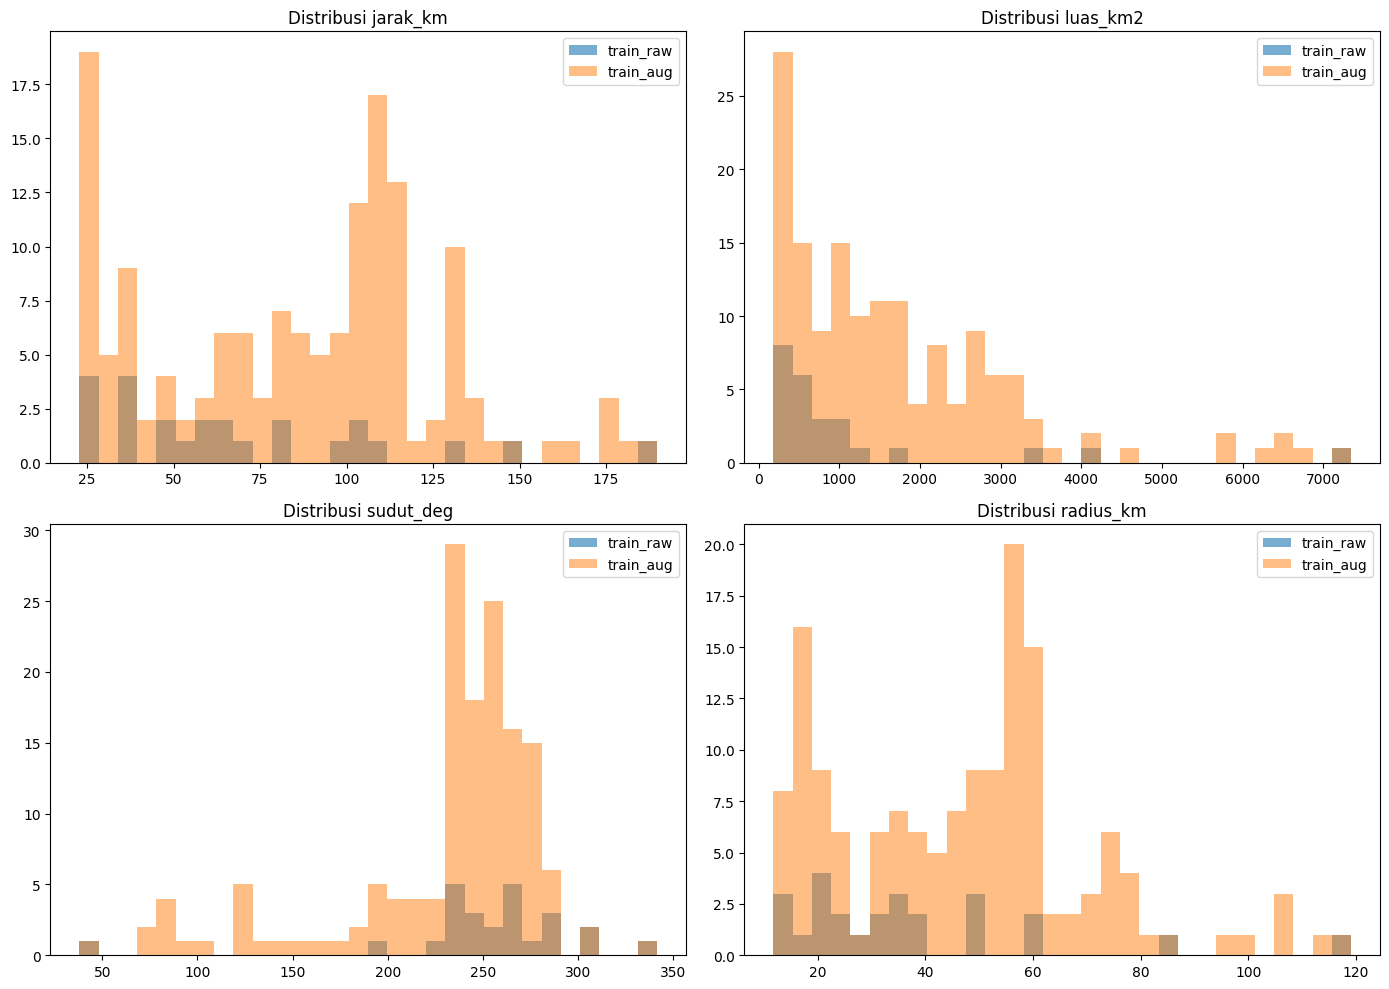

Waktu plot_distribution: 1.516814 detik


In [10]:
# Ringkasan distribusi target sebelum vs sesudah augmentasi (train)
step_start = perf_counter()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, tgt in enumerate(TARGET_COLS):
    ax = axes[idx]
    ax.hist(y_train_raw[tgt], bins=30, alpha=0.6, label='train_raw')
    ax.hist(y_train_aug_raw[tgt], bins=30, alpha=0.5, label='train_aug')
    ax.set_title(f'Distribusi {tgt}')
    ax.legend()

plt.tight_layout()
fig.savefig(REPORT_DIR / 'target_distribution_train_raw_vs_aug.png', dpi=140, bbox_inches='tight')
plt.show()

process_times['plot_distribution'] = perf_counter() - step_start
print(f'Waktu plot_distribution: {process_times["plot_distribution"]:.6f} detik')

In [11]:
# Rekap waktu proses
timing_df = pd.DataFrame([{'process': k, 'duration_seconds': v} for k, v in process_times.items()])
timing_df = timing_df.sort_values('duration_seconds', ascending=False).reset_index(drop=True)
timing_df.to_csv(REPORT_DIR / 'process_times.csv', index=False)
display(timing_df)
print('Rekap waktu tersimpan di:', REPORT_DIR / 'process_times.csv')

,process,duration_seconds
0,plot_distribution,1.516814
1,feature_engineering,0.162068
2,feature_selection,0.100170
3,smote_augmentation,0.043860
4,split_data,0.029871
5,save_outputs,0.022980
6,scaling,0.013381
7,load_data,0.006750
8,setup,0.001593


Rekap waktu tersimpan di: preprocessing_outputs_merapi_smote_v2\reports\process_times.csv
